# Flight Box Generation

The `flight_box` module generates parallel flight lines covering a geographic
area. Given a sensor, altitude, and study area, it computes how many lines are
needed for the desired swath overlap and returns a list of `FlightLine` objects.

Two entry points are provided:

| Function | Use case |
|----------|----------|
| `box_around_center_line` | Define a box by center point, length, width, and azimuth |
| `box_around_polygon` | Automatically fit lines to cover an arbitrary polygon |

We cover:

1. Basic box around a center line
2. Controlling overlap and line direction
3. Generating lines from a polygon (auto-azimuth)
4. Generating lines from a polygon with a user-defined azimuth
5. Clipping lines to a polygon boundary
6. Visualizing swath coverage

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon

from hyplan import (
    AVIRIS3, AVIRISClassic, HyTES,
    box_around_center_line, box_around_polygon,
    generate_swath_polygon, calculate_swath_widths,
    ureg,
)

## 1. Basic Box Around a Center Line

`box_around_center_line` creates parallel flight lines centered on a given
lat/lon point. You specify the box dimensions (length and width), azimuth,
and overlap percentage. The sensor's swath width at the flight altitude
determines line spacing.

In [2]:
sensor = AVIRIS3()
altitude = ureg.Quantity(20000, "feet")

# Swath width at this altitude determines line spacing
swath = sensor.swath_width(altitude)
print(f"Sensor: {sensor.name}")
print(f"Swath width at {altitude}: {swath.to(ureg.meter):.0f}")

# Generate flight lines over a 30 km x 15 km box near Monterey Bay
lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=altitude,
    lat0=36.8,
    lon0=-121.9,
    azimuth=0.0,           # north-south lines
    box_length=ureg.Quantity(30, "km"),
    box_width=ureg.Quantity(15, "km"),
    box_name="MB",
    overlap=20.0,          # 20% swath overlap
)

print(f"\nGenerated {len(lines)} flight lines")
for fl in lines:
    print(f"  {fl.site_name}: {fl.length.to(ureg.km):.1f}, az={fl.az12.magnitude:.1f}°")

Sensor: AVIRIS 3
Swath width at 20000 foot: 4389 meter

Generated 5 flight lines
  MB_L01_FL200: 30.0 kilometer, az=180.0°
  MB_L02_FL200: 30.0 kilometer, az=360.0°
  MB_L03_FL200: 30.0 kilometer, az=180.0°
  MB_L04_FL200: 30.0 kilometer, az=0.0°
  MB_L05_FL200: 30.0 kilometer, az=180.0°


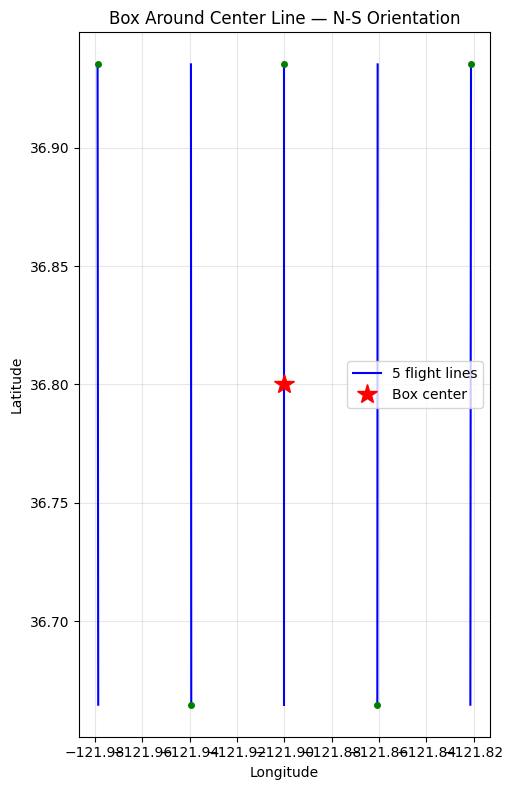

In [3]:
# Visualize the flight lines
fig, ax = plt.subplots(figsize=(8, 8))
for fl in lines:
    x, y = fl.geometry.xy
    ax.plot(x, y, "b-", linewidth=1.5)
    ax.plot(x[0], y[0], "go", markersize=4)  # start point

ax.plot([], [], "b-", label=f"{len(lines)} flight lines")
ax.plot(-121.9, 36.8, "r*", markersize=15, label="Box center")
ax.set_title("Box Around Center Line — N-S Orientation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Controlling Overlap and Line Direction

The `overlap` parameter controls how much adjacent swaths overlap (0–100%).
Higher overlap means more lines but better coverage redundancy.

The `alternate_direction` parameter alternates the flight direction of successive
lines ("lawnmower" pattern), reducing transit time between lines.

The `starting_point` parameter controls whether the first line starts at the
"edge" or "center" of the box.

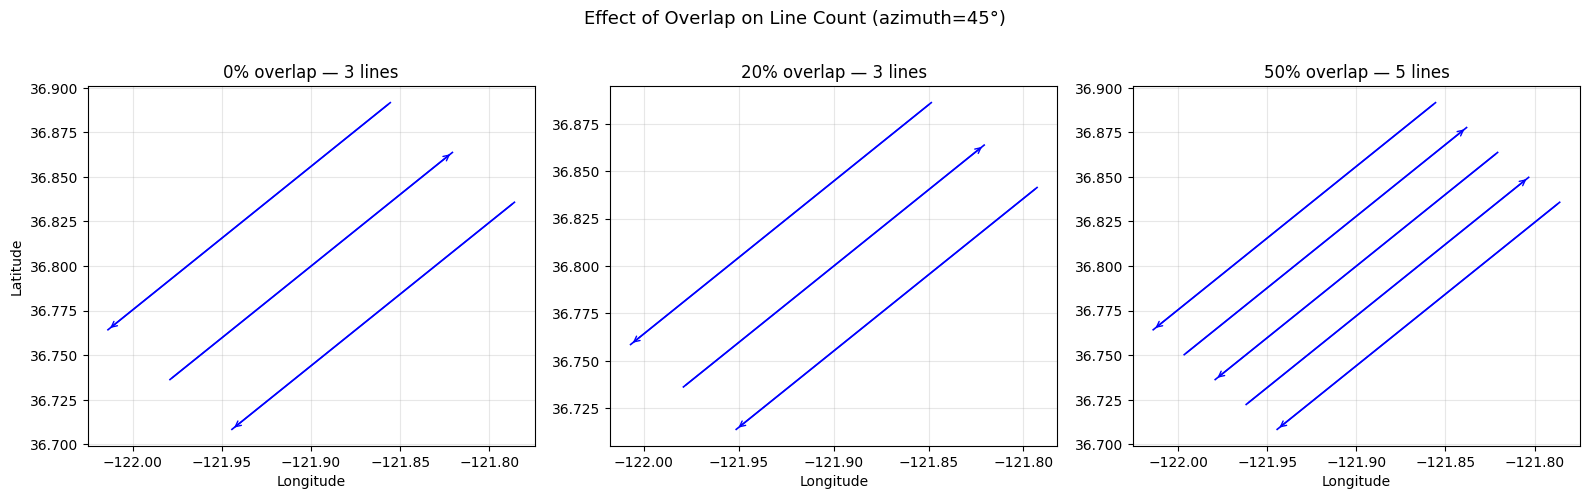

In [4]:
# Compare different overlap percentages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, overlap in zip(axes, [0, 20, 50]):
    fls = box_around_center_line(
        instrument=sensor,
        altitude_msl=altitude,
        lat0=36.8, lon0=-121.9,
        azimuth=45.0,
        box_length=ureg.Quantity(20, "km"),
        box_width=ureg.Quantity(10, "km"),
        overlap=overlap,
        alternate_direction=True,
    )
    for fl in fls:
        x, y = fl.geometry.xy
        ax.plot(x, y, "b-", linewidth=1.2)
        ax.annotate("", xy=(x[-1], y[-1]), xytext=(x[0], y[0]),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=1))

    ax.set_title(f"{overlap}% overlap — {len(fls)} lines")
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Latitude")
plt.suptitle("Effect of Overlap on Line Count (azimuth=45°)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Box Around a Polygon (Auto-Azimuth)

`box_around_polygon` automatically computes the minimum rotated rectangle
of the polygon and aligns flight lines along its longest axis. This
minimizes the number of lines needed to cover an irregular study area.

We define a study area polygon (a simplified coastline) and generate lines.

Generated 5 lines (auto-azimuth)
Azimuth: 99.1°


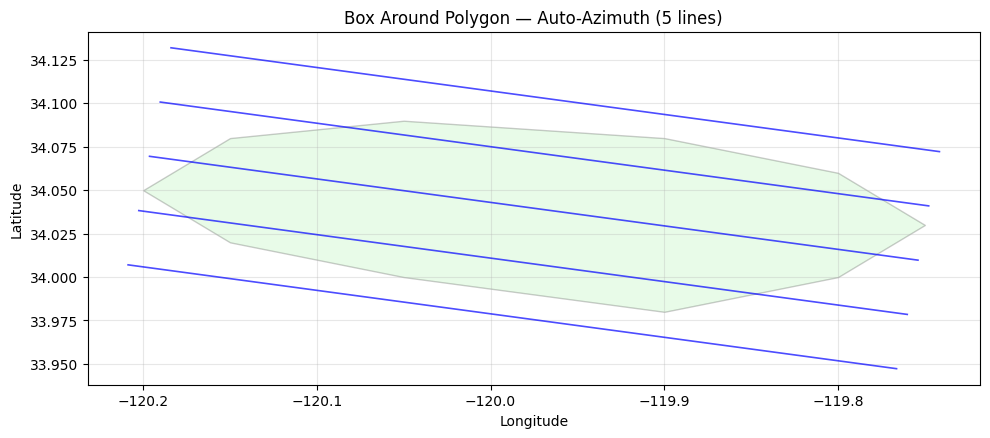

In [5]:
# Define a study area polygon (simplified island shape)
study_area = Polygon([
    (-120.20, 34.05), (-120.15, 34.02), (-120.05, 34.00),
    (-119.90, 33.98), (-119.80, 34.00), (-119.75, 34.03),
    (-119.80, 34.06), (-119.90, 34.08), (-120.05, 34.09),
    (-120.15, 34.08), (-120.20, 34.05),
])

# Generate flight lines covering the polygon
poly_lines = box_around_polygon(
    instrument=sensor,
    altitude_msl=altitude,
    polygon=study_area,
    box_name="ISL",
    overlap=20.0,
    alternate_direction=True,
    clip_to_polygon=False,  # don't clip yet
)

print(f"Generated {len(poly_lines)} lines (auto-azimuth)")
print(f"Azimuth: {poly_lines[0].az12.magnitude:.1f}°")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.2, edgecolor="black", color="lightgreen")

for fl in poly_lines:
    x, y = fl.geometry.xy
    ax.plot(x, y, "b-", linewidth=1.2, alpha=0.7)

ax.set_title(f"Box Around Polygon — Auto-Azimuth ({len(poly_lines)} lines)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. User-Defined Azimuth

You can override the automatic azimuth by specifying one explicitly.
This is useful when flight line orientation is constrained by wind,
solar geometry, or airspace restrictions.

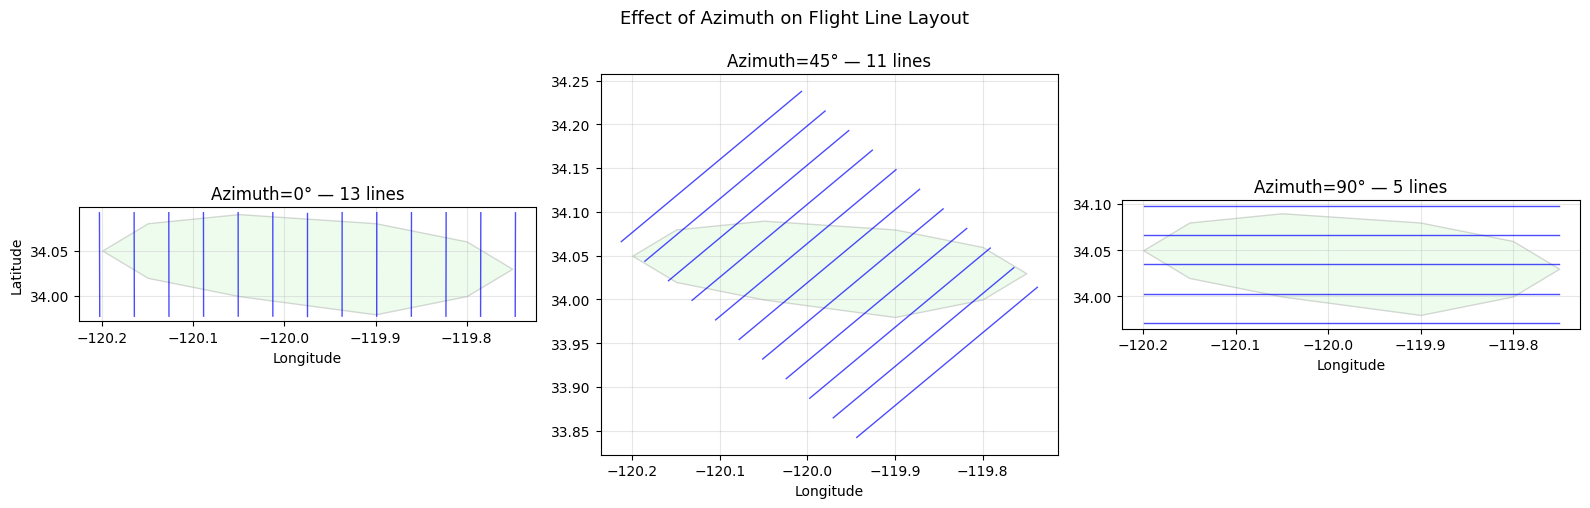

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, azimuth in zip(axes, [0.0, 45.0, 90.0]):
    fls = box_around_polygon(
        instrument=sensor,
        altitude_msl=altitude,
        polygon=study_area,
        azimuth=azimuth,
        overlap=20.0,
        clip_to_polygon=False,
    )
    gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.15, edgecolor="black", color="lightgreen")
    for fl in fls:
        x, y = fl.geometry.xy
        ax.plot(x, y, "b-", linewidth=1, alpha=0.7)

    ax.set_title(f"Azimuth={azimuth:.0f}° — {len(fls)} lines")
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Latitude")
plt.suptitle("Effect of Azimuth on Flight Line Layout", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Clipping Lines to a Polygon

Setting `clip_to_polygon=True` trims flight lines to the polygon boundary.
This avoids wasting flight time over areas outside the study region.

Lines that fall entirely outside the polygon are removed. Lines that
partially overlap are clipped, potentially splitting into multiple segments.

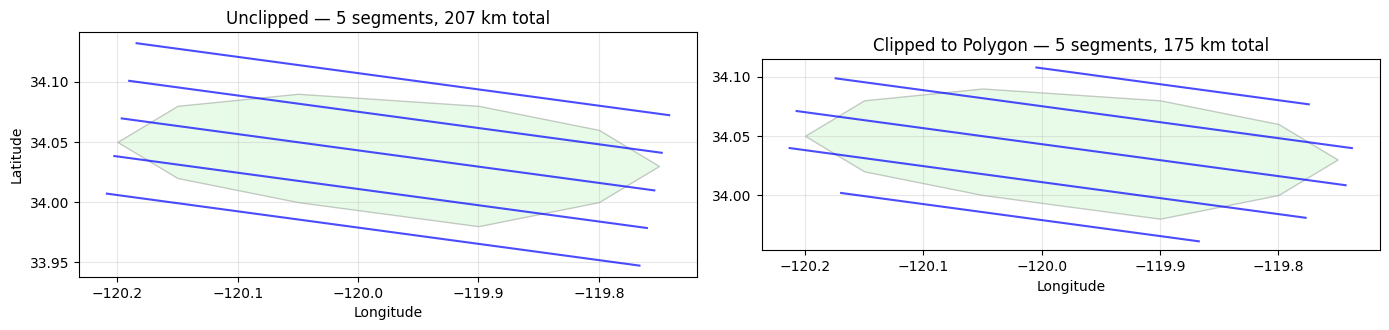

In [7]:
# Compare clipped vs. unclipped
clipped_lines = box_around_polygon(
    instrument=sensor,
    altitude_msl=altitude,
    polygon=study_area,
    overlap=20.0,
    clip_to_polygon=True,
)

unclipped_lines = box_around_polygon(
    instrument=sensor,
    altitude_msl=altitude,
    polygon=study_area,
    overlap=20.0,
    clip_to_polygon=False,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fls, title in zip(axes,
                          [unclipped_lines, clipped_lines],
                          ["Unclipped", "Clipped to Polygon"]):
    gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.2, edgecolor="black", color="lightgreen")
    total_km = 0
    for fl in fls:
        x, y = fl.geometry.xy
        ax.plot(x, y, "b-", linewidth=1.5, alpha=0.7)
        total_km += fl.length.to(ureg.km).magnitude

    ax.set_title(f"{title} — {len(fls)} segments, {total_km:.0f} km total")
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 6. Interactive Swath Coverage Map

Use Folium to visualize flight lines and their swath footprints on an
interactive map. Each swath polygon is color-coded to match its flight line.

In [8]:
# Generate swath polygons for each flight line on an interactive map
import folium

centroid = study_area.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=11,
               tiles="CartoDB positron")

# Study area polygon
folium.GeoJson(
    study_area.__geo_interface__,
    style_function=lambda x: {"fillColor": "green", "color": "black",
                               "weight": 2, "fillOpacity": 0.15},
    name="Study Area",
).add_to(m)

# Flight lines with swath polygons
colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
          "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990"]

for i, fl in enumerate(unclipped_lines):
    color = colors[i % len(colors)]
    # Swath polygon
    try:
        swath_poly = generate_swath_polygon(fl, sensor)
        folium.GeoJson(
            swath_poly.__geo_interface__,
            style_function=lambda x, c=color: {"fillColor": c, "color": c,
                                                "weight": 1, "fillOpacity": 0.15},
        ).add_to(m)
    except Exception:
        pass
    # Flight line
    coords = [(lat, lon) for lon, lat in fl.geometry.coords]
    folium.PolyLine(coords, color=color, weight=2, tooltip=fl.site_name).add_to(m)

m

In [9]:
# Swath width statistics for each line
print(f"{'Line':<20s} {'Min (m)':>8s} {'Mean (m)':>9s} {'Max (m)':>8s}")
print("-" * 48)
for fl in unclipped_lines[:5]:  # first 5 lines
    try:
        swath_poly = generate_swath_polygon(fl, sensor)
        widths = calculate_swath_widths(swath_poly)
        print(f"{fl.site_name:<20s} {widths['min_width']:>8.0f} {widths['mean_width']:>9.0f} {widths['max_width']:>8.0f}")
    except Exception as e:
        print(f"{fl.site_name:<20s} (error: {e})")

# Compare with theoretical
theoretical = sensor.swath_width(altitude).to(ureg.meter).magnitude
print(f"\nTheoretical swath width at {altitude}: {theoretical:.0f} m")

Line                  Min (m)  Mean (m)  Max (m)
------------------------------------------------
Line_L01_FL200           4232      4344     4391
Line_L02_FL200           4215      4357     4391
Line_L03_FL200           4069      4320     4391
Line_L04_FL200           4137      4347     4391
Line_L05_FL200           4333      4385     4391

Theoretical swath width at 20000 foot: 4389 m


## 7. Comparing Sensors

Different sensors produce different swath widths at the same altitude,
which affects the number of lines needed to cover the same area.

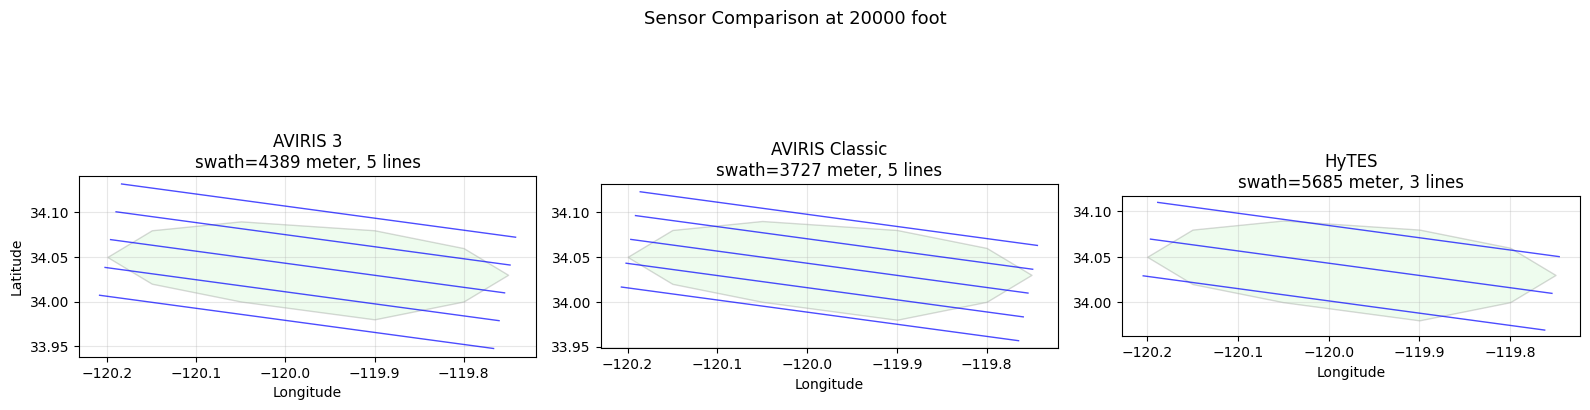

In [10]:
sensors = [AVIRIS3(), AVIRISClassic(), HyTES()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, s in zip(axes, sensors):
    sw = s.swath_width(altitude).to(ureg.meter)
    fls = box_around_polygon(
        instrument=s,
        altitude_msl=altitude,
        polygon=study_area,
        overlap=20.0,
        clip_to_polygon=False,
    )
    gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.15, edgecolor="black", color="lightgreen")
    for fl in fls:
        x, y = fl.geometry.xy
        ax.plot(x, y, "b-", linewidth=1, alpha=0.7)

    ax.set_title(f"{s.name}\nswath={sw:.0f}, {len(fls)} lines")
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Latitude")
plt.suptitle(f"Sensor Comparison at {altitude}", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Line Naming and Numbering

The `box_name` and `start_numbering` parameters control flight line names.
Names follow the pattern `{box_name}_L{number}_{flight_level}`.

In [11]:
# Custom naming
named_lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=ureg.Quantity(25000, "feet"),
    lat0=36.8, lon0=-121.9,
    azimuth=90.0,
    box_length=ureg.Quantity(20, "km"),
    box_width=ureg.Quantity(8, "km"),
    box_name="Coast",
    start_numbering=10,
    overlap=15.0,
)

print("Flight line names:")
for fl in named_lines:
    print(f"  {fl.site_name}")

Flight line names:
  Coast_L10_FL250
  Coast_L11_FL250
  Coast_L12_FL250


## Summary

| Function | Purpose |
|----------|---------|
| `box_around_center_line(instrument, altitude, lat0, lon0, azimuth, box_length, box_width, ...)` | Generate lines from a center point and box dimensions |
| `box_around_polygon(instrument, altitude, polygon, ...)` | Generate lines to cover an arbitrary polygon |

**Key parameters:**
- `overlap` — Percentage overlap between adjacent swaths (0–100)
- `alternate_direction` — Alternate line directions for efficient lawnmower patterns
- `starting_point` — Start from `"edge"` or `"center"` of the box
- `azimuth` — Flight line orientation; auto-computed from polygon if `None`
- `clip_to_polygon` — Trim lines to the polygon boundary
- `box_name` / `start_numbering` — Control line naming convention